# Entregable 6: Desercion Escolar en Zonas Rurales
## Analisis con Dask (2020-2024)

Analisis exploratorio de la desercion escolar en zonas rurales usando Dask
para procesamiento escalable.

In [1]:
import dask.dataframe as dd
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('Librerias cargadas')

Librerias cargadas


/home/mrdavidalv/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Lectura con Dask DataFrame

In [2]:
ddf = dd.read_csv('6 Desercion_Escolar_Rural.csv')

print(f'Columnas: {list(ddf.columns)}')
print(f'Particiones: {ddf.npartitions}')
ddf.head(10)

Columnas: ['Año', 'Departamento', 'Institución', 'Matrícula_Inicial', 'Matrícula_Final', 'Tasa_Deserción', 'Causa_Probable', 'Estrato_Promedio', 'Distancia_Promedio_Km']
Particiones: 1


,Año,Departamento,Institución,Matrícula_Inicial,Matrícula_Final,Tasa_Deserción,Causa_Probable,Estrato_Promedio,Distancia_Promedio_Km
0,2020,Amazonas,Ellis-Gray Rural,239,209,0.125,Trabajo infantil,1.4,6.58
1,2021,Cauca,Johnson Ltd Rural,223,202,0.093,Otro,1.1,4.56
2,2023,Amazonas,Little Inc Rural,57,51,0.088,Económica,1.3,0.30
3,2024,Amazonas,"Gallegos, Benson and Hill Rural",193,176,0.088,Migración,2.1,10.06
4,2024,Casanare,Mueller-Miller Rural,106,87,0.179,Acceso,1.9,0.10
5,2020,La Guajira,"Pierce, Kirby and Martinez Rural",228,196,0.138,Acceso,1.5,17.52
6,2021,Nariño,Alvarado-Ortiz Rural,295,272,0.077,Trabajo infantil,1.2,1.00
7,2023,Cauca,Stephenson and Sons Rural,141,123,0.127,Trabajo infantil,1.9,1.01
8,2020,Meta,Collier Ltd Rural,187,166,0.112,Económica,2.5,2.83
9,2023,Cauca,"Moore, Stone and Johnson Rural",191,190,0.004,Trabajo infantil,2.2,1.72


In [3]:
print('Estadisticas:')
print(ddf.describe().compute().round(3))

Estadisticas:
            Año  Matrícula_Inicial  Matrícula_Final  Tasa_Deserción  \
count  2000.000           2000.000         2000.000        2000.000   
mean   2022.024            176.374          157.857           0.102   
std       1.426             71.890           65.183           0.049   
min    2020.000             50.000           42.000           0.000   
25%    2021.000            114.000          103.000           0.068   
50%    2022.000            176.000          156.000           0.102   
75%    2023.000            240.000          215.000           0.133   
max    2024.000            300.000          298.000           0.296   

       Estrato_Promedio  Distancia_Promedio_Km  
count          2000.000               2000.000  
mean              1.753                  4.882  
std               0.437                  4.821  
min               1.000                  0.000  
25%               1.400                  1.390  
50%               1.700                  3.390  
75%

In [4]:
df_pd = ddf.compute()
print(f'Total registros: {len(df_pd)}')
print(f'Departamentos: {df_pd["Departamento"].nunique()}')
print(f'Instituciones: {df_pd["Institución"].nunique()}')
print(f'Causas: {list(df_pd["Causa_Probable"].unique())}')
print(f'Periodo: {df_pd["Año"].min()} - {df_pd["Año"].max()}')

Total registros: 2000
Departamentos: 9
Instituciones: 1906
Causas: ['Trabajo infantil', 'Otro', 'Económica', 'Migración', 'Acceso']
Periodo: 2020 - 2024


## 2. Analisis por ano

In [5]:
por_anio = ddf.groupby('Año').agg({
    'Tasa_Deserción': 'mean',
    'Matrícula_Inicial': 'sum',
    'Matrícula_Final': 'sum'
}).compute()
por_anio['Desertores'] = por_anio['Matrícula_Inicial'] - por_anio['Matrícula_Final']
print('Desercion por ano:')
por_anio.round(4)

Desercion por ano:


,Tasa_Deserción,Matrícula_Inicial,Matrícula_Final,Desertores
Año,,,,
2020,0.1016,73646,65943,7703
2021,0.1046,64216,57310,6906
2023,0.1015,71784,64076,7708
2024,0.0982,72590,65347,7243
2022,0.1041,70512,63038,7474


## 3. Analisis por causa

In [6]:
por_causa = df_pd.groupby('Causa_Probable').agg({
    'Tasa_Deserción': ['count', 'mean']
}).round(4)
por_causa.columns = ['Frecuencia', 'Tasa_Promedio']
por_causa = por_causa.sort_values('Frecuencia', ascending=False)
print('Causas de desercion:')
por_causa

Causas de desercion:


,Frecuencia,Tasa_Promedio
Causa_Probable,,
Acceso,424,0.1040
Trabajo infantil,405,0.1021
Otro,397,0.1028
Migración,392,0.0990
Económica,382,0.1016


## 4. Analisis por departamento

In [7]:
por_depto = ddf.groupby('Departamento').agg({
    'Tasa_Deserción': 'mean',
    'Matrícula_Inicial': 'sum'
}).compute()
por_depto.columns = ['Tasa_Promedio', 'Total_Estudiantes']
por_depto = por_depto.sort_values('Tasa_Promedio', ascending=False)
print('Top 15 departamentos con mayor desercion:')
por_depto.round(4).head(15)

Top 15 departamentos con mayor desercion:


,Tasa_Promedio,Total_Estudiantes
Departamento,,
Chocó,0.1062,39126
Cauca,0.1047,42410
La Guajira,0.1038,34508
Guaviare,0.1035,38092
Amazonas,0.1032,35132
Nariño,0.1026,43575
Putumayo,0.1026,39198
Meta,0.0960,43999
Casanare,0.0946,36708


## 5. Correlaciones

In [8]:
vars_corr = ['Tasa_Deserción', 'Estrato_Promedio', 'Distancia_Promedio_Km', 'Matrícula_Inicial']
corr = df_pd[vars_corr].corr().round(3)
print('Matriz de correlacion:')
corr

Matriz de correlacion:


,Tasa_Deserción,Estrato_Promedio,Distancia_Promedio_Km,Matrícula_Inicial
Tasa_Deserción,1.000,-0.011,0.007,0.018
Estrato_Promedio,-0.011,1.000,-0.001,-0.013
Distancia_Promedio_Km,0.007,-0.001,1.000,-0.024
Matrícula_Inicial,0.018,-0.013,-0.024,1.000


## 6. Visualizaciones

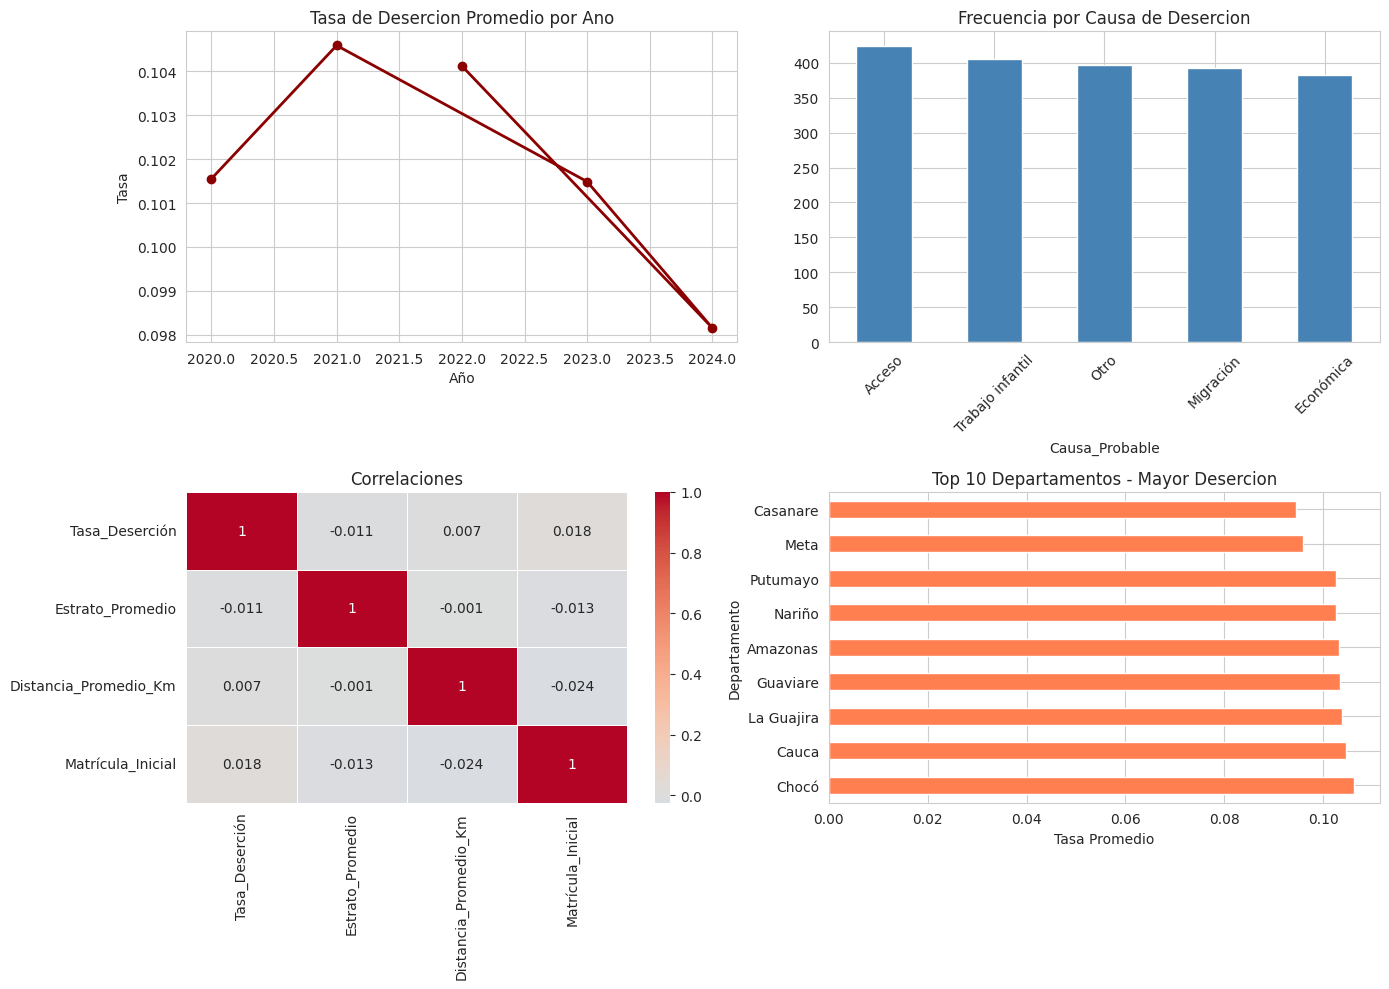

Graficos guardados


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

por_anio['Tasa_Deserción'].plot(marker='o', linewidth=2, color='darkred', ax=axes[0,0])
axes[0,0].set_title('Tasa de Desercion Promedio por Ano')
axes[0,0].set_ylabel('Tasa')

por_causa['Frecuencia'].plot(kind='bar', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Frecuencia por Causa de Desercion')
axes[0,1].tick_params(axis='x', rotation=45)

sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=axes[1,0], linewidths=0.5)
axes[1,0].set_title('Correlaciones')

por_depto['Tasa_Promedio'].head(10).plot(kind='barh', ax=axes[1,1], color='coral')
axes[1,1].set_title('Top 10 Departamentos - Mayor Desercion')
axes[1,1].set_xlabel('Tasa Promedio')

plt.tight_layout()
plt.savefig('visualizaciones_desercion.png', dpi=150)
plt.show()
print('Graficos guardados')

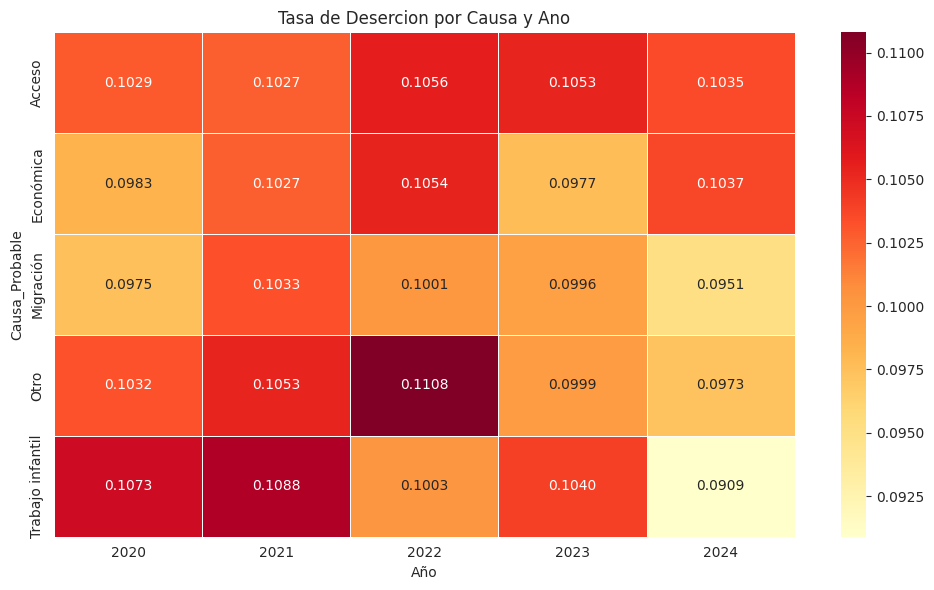

Grafico guardado


In [10]:
# Mapa de calor: desercion por causa y ano
causa_anio = df_pd.pivot_table(values='Tasa_Deserción', index='Causa_Probable',
                                columns='Año', aggfunc='mean').round(4)

plt.figure(figsize=(10, 6))
sns.heatmap(causa_anio, annot=True, cmap='YlOrRd', linewidths=0.5, fmt='.4f')
plt.title('Tasa de Desercion por Causa y Ano')
plt.tight_layout()
plt.savefig('heatmap_causa_anio.png', dpi=150)
plt.show()
print('Grafico guardado')

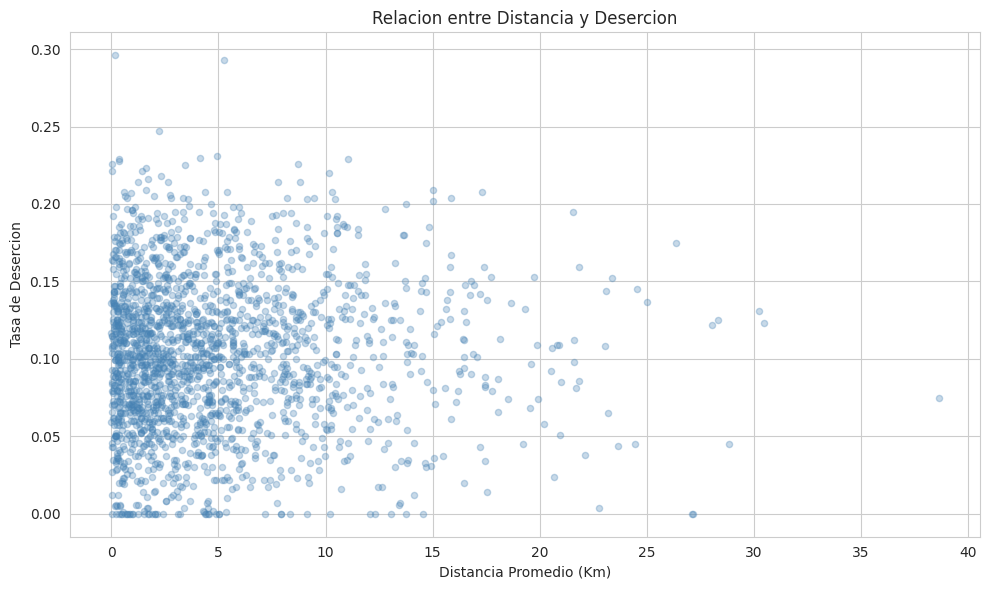

Grafico guardado


In [11]:
# Scatter: distancia vs desercion
plt.figure(figsize=(10, 6))
plt.scatter(df_pd['Distancia_Promedio_Km'], df_pd['Tasa_Deserción'],
            alpha=0.3, color='steelblue', s=20)
plt.xlabel('Distancia Promedio (Km)')
plt.ylabel('Tasa de Desercion')
plt.title('Relacion entre Distancia y Desercion')
plt.tight_layout()
plt.savefig('scatter_distancia_desercion.png', dpi=150)
plt.show()
print('Grafico guardado')

## 7. Narrativa tecnica

La desercion escolar en zonas rurales responde a multiples factores. Las causas mas
reportadas se concentran en pocas categorias, lo que facilita focalizar politicas.
A nivel departamental hay diferencias marcadas que justifican intervenciones
diferenciadas.

Dask resulto adecuado para este analisis: la lectura por particiones y las operaciones
de agrupacion distribuida funcionan bien con los 2,000 registros actuales y escalarian
sin problemas a volumenes mayores.